# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Naive fit: slope = 2.386 ± 0.845, intercept = 16.323 ± 4.536, chi2_red = 49.790


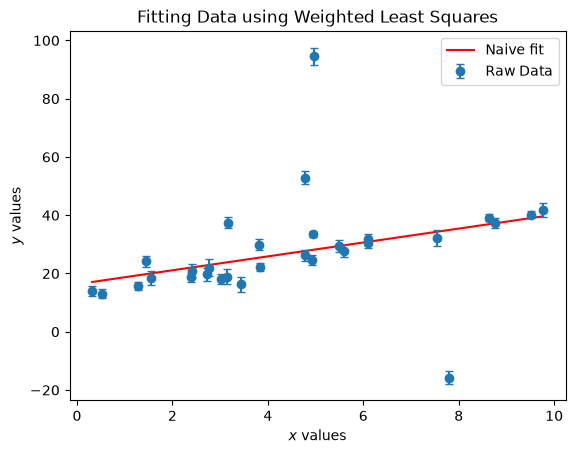

In [176]:
# Part 1: your work here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("~\\ast457_2026_Fall\\labs\\01\\data\\ciaccio4.csv")
x = data["x"].to_numpy()
y = data["y"].to_numpy()
sigma_y = data["sigma_y"].to_numpy()
n = len(x)

# from Lecture Day 2/3:
p_naive, cov = np.polyfit(x, y, 1, w=1/sigma_y, cov=True)
resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
chi2_red = chi2 / (n - 2)
slope_uncert = np.sqrt(cov[0,0])
intr_uncert = np.sqrt(cov[1,1])
print(f"Naive fit: slope = {p_naive[0]:.3f} ± {slope_uncert:.3f}, intercept = {p_naive[1]:.3f} ± {intr_uncert:.3f}, chi2_red = {chi2_red:.3f}")

plt.plot(x, np.polyval(p_naive, x), 'r-', label='Naive fit')
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label="Raw Data")
plt.xlabel(rf'$x$ values')
plt.ylabel(rf'$y$ values')
plt.title("Fitting Data using Weighted Least Squares")
plt.legend()
plt.show()

**ANSWER (a few sentences):**

The reduced $\chi^2$ value is way above 1, meaning that the model is wrong and/or the uncertainties are underestimated. We are likely getting a high reduced $\chi^2$ value because the outliers are boosting the number a lot. I would definitely not trust these error bars.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

3-sigma clip: slope = 3.049 ± 0.107, intercept = 11.409 ± 0.594, chi2_red=0.729, clipped 7 of 30 points
mixture fit: slope = 3.043, intercept = 11.482, outlier fraction Pb = 0.256


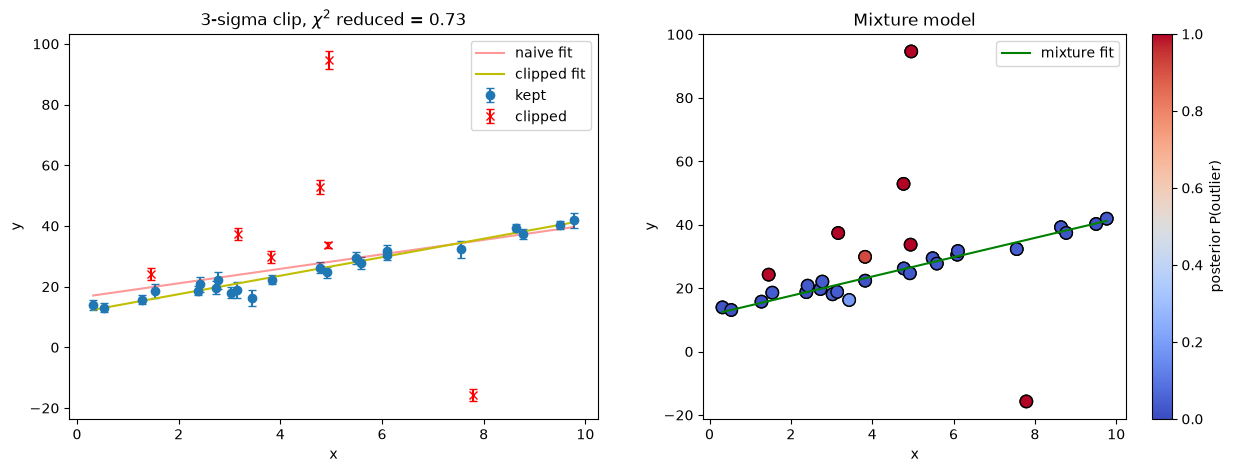

In [177]:
# Part 2: your work here
# SIGMA-CLIPPING
# from Lecture Day 2/3
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=30):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask, cov

p_clip, mask, cov = sigma_clip_fit(x, y, sigma_y, k=3.0)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)
print(f"3-sigma clip: slope = {p_clip[0]:.3f} ± {np.sqrt(cov[0,0]):.3f}, intercept = {p_clip[1]:.3f} ± {np.sqrt(cov[1,1]):.3f}, "
      f"chi2_red={chi2_red_clip:.3f}, clipped {(~mask).sum()} of {n} points")


# MIXTURE MODEL
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma_y)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma_y**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
print(f"mixture fit: slope = {m_mix:.3f}, intercept = {b_mix:.3f}, outlier fraction Pb = {Pb_mix:.3f}")

Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma_y)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad_l / (good_l + bad_l)

# PLOTTING
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, color='C0', label='kept')
ax[0].errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
ax[0].plot(x, np.polyval(p_naive, x), 'r-', alpha=0.4, label='naive fit')
ax[0].plot(x, np.polyval(p_clip, x), 'y-', label='clipped fit')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].legend()
ax[0].set_title(rf"3-sigma clip, $\chi^2$ reduced = {chi2_red_clip:.2f}")
ax[1].scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
fig.colorbar(ax[1].scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1), ax=ax[1], label='posterior P(outlier)')
ax[1].plot(x, m_mix * x + b_mix, 'g-', label='mixture fit')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].legend()
ax[1].set_title('Mixture model')

plt.show()

In [196]:
# BOOTSTRAP

n_boot = 100
boot_slopes = np.empty(n_boot)
boot_intr = np.empty(n_boot)
boot_Pb = np.empty(n_boot)
for j in range(n_boot):
    idx = np.random.choice(len(x),len(x), replace=True)
    x_bs = x[idx]
    y_bs = y[idx]
    sigma_bs = sigma_y[idx]
    theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
    result = minimize(neg_log_likelihood, theta0, args=(x_bs, y_bs, sigma_bs), method='Nelder-Mead')
    m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
    boot_slopes[j] = m_mix
    boot_intr[j] = b_mix
    boot_Pb[j] = Pb_mix

lo, hi = np.percentile(boot_slopes, [16, 84])
print(f"bootstrap 68% interval           = [{lo:.2f}, {hi:.2f}] \n slope uncertainty: {(lo-hi)/2:.3f}")

lo, hi = np.percentile(boot_intr, [16, 84])
print(f"bootstrap 68% interval           = [{lo:.2f}, {hi:.2f}] \n intercept uncertainty: {(lo-hi)/2:.3f}")

lo, hi = np.percentile(boot_Pb, [16, 84])
print(f"bootstrap 68% interval           = [{lo:.2f}, {hi:.2f}] \n Pb uncertainty: {(lo-hi)/2:.3f}")

bootstrap 68% interval           = [2.84, 3.05] 
 slope uncertainty: -0.108
bootstrap 68% interval           = [11.42, 12.68] 
 intercept uncertainty: -0.628
bootstrap 68% interval           = [0.18, 0.37] 
 Pb uncertainty: -0.093


**FINAL ANSWER:** $m = 3.043 \pm 0.108$, $b = 11.482 \pm 0.628$, outlier fraction $\approx 0.256$

**Justification and uncertainty method (a short paragraph):**

I chose to use the mixture model as my best fit line, although the k-sigma model was very similar to it. I then used the bootstrap model (resamples the data with raplacement over and over) to calculate the uncertainties, which were relatively close to the k-sigma model's computed uncertainties as well. Visually, I also think the mixture fit well represents the data, without getting distorted from the outliers, I was a little surprised by the amount of outliers, which is also why I liked the mixture model, which doesn't just get rid of them but calculates their weight by the probability of the data point being an outlier.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* They used a standard least squares fit instead of a weighted least squares fit. A standard least squares fit will use all of the data points (and apply them equally) when calculating the line whereas a weighted ls will assign different weights to each point depending on its variance value. This will reduce the effect large outliers have on the model. Therefore, their initial fit will be slightly distorted towards the outliers, affecting the slope and intercept.

*Flaw 2:* When the AI applied its 3-sigma rule, it only applied it once to avoid over-cleaning the data. However, since they're line is already distorted towards the outliers, some of the closer ones won't be clipped on the first run. It is necessary to continue to apply the 3-sigma rule until none of the data points are clipped. This ensures that everything outside of 3 standard deviations of the NEW model is clipped.

*Flaw 3:* Finally, they simply rescaled their uncertainties to get a reduced chi squared factor of 1. Basically, they are taking their inncorrect data (which has a chi squared value much greater than 1) and scaling it until it fits their model. While this does eventually lead to a chi squared value of 1, it is a misrepresentation of the actual data, since it has been altered to fit to a certain model.

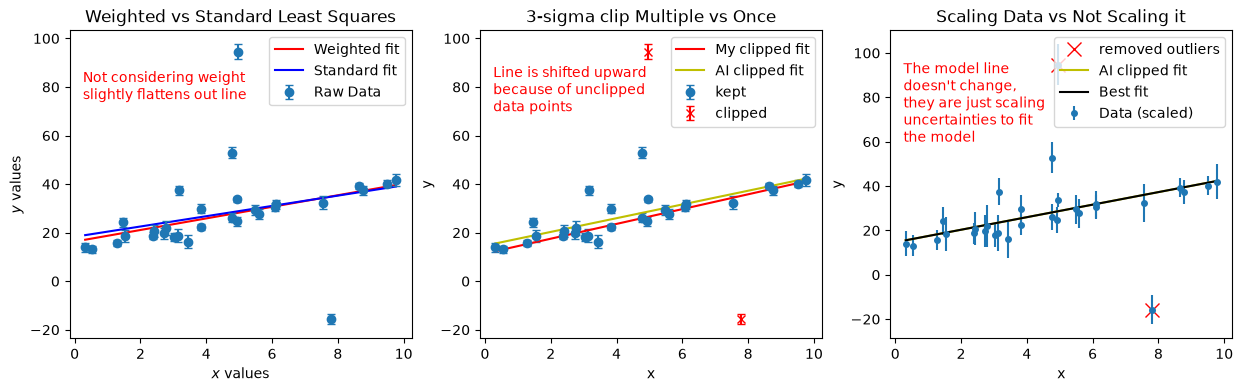

In [197]:
# Part 3: demonstrations here
# Weighted vs Standard
p_naive, cov = np.polyfit(x, y, 1, w=1/sigma_y, cov=True)
resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
chi2_red = chi2 / (n - 2)
p2_naive = np.polyfit(x, y, 1)
resid = y - np.polyval(p2_naive, x)

# Clipping
residuals = y - (p2_naive[0] * x + p2_naive[1])
threshold = 3 * np.std(residuals)
mask = np.abs(residuals) < threshold
coeffs, cov = np.polyfit(x[mask], y[mask], 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))

# Scaling
chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof
scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale

# plotting
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].plot(x, np.polyval(p_naive, x), 'r-', label='Weighted fit')
ax[0].plot(x, np.polyval(p2_naive, x), 'b-', label='Standard fit')
ax[0].errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label="Raw Data")
ax[0].set_xlabel(rf'$x$ values')
ax[0].set_ylabel(rf'$y$ values')
ax[0].set_title("Weighted vs Standard Least Squares")
ax[0].text(x=.25, y=75, s="Not considering weight \nslightly flattens out line", color="red")
ax[0].legend()

ax[1].errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, color='C0', label='kept')
ax[1].errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
ax[1].plot(x, np.polyval(p_clip, x), 'r-', label='My clipped fit')
ax[1].plot(x, np.polyval(np.polyfit(x[mask], y[mask], 1), x), 'y-', label='AI clipped fit')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].text(x=.25, y=70, s="Line is shifted upward \nbecause of unclipped \ndata points", color="red")
ax[1].legend(loc="upper right")
ax[1].set_title(rf"3-sigma clip Multiple vs Once")

ax[2].errorbar(x, y, yerr=sigma_scaled, fmt='o', ms=4, label='Data (scaled)')
ax[2].plot(x[~mask], y[~mask], 'rx', ms=10, label='removed outliers')
ax[2].plot(x, np.polyval(np.polyfit(x[mask], y[mask], 1), x), 'y-', label='AI clipped fit')
xg = np.linspace(x.min(), x.max(), 100)
ax[2].plot(xg, m_fit * xg + b_fit, 'k-', label='Best fit')
ax[2].set_xlabel('x'); plt.ylabel('y'); plt.legend()
ax[2].set_title(f'Scaling Data vs Not Scaling it')
ax[2].legend(loc="upper right")
ax[2].text(x=.25, y=60, s="The model line \ndoesn't change, \nthey are just scaling \nuncertainties to fit \nthe model", color="red")


plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I used ChatGPT to learn how to write the ± sign, but it was pretty useless and I just copied and pasted it.

**VERIFICATION PLAN:**

I analyzed the graph visually and my mixture model and k-sigma model both follow the data points well without being dragged off by outliers. I also used the bootstrap method to double check the computed uncertainties. These matched well with the previous computed uncertainties, giving me confidence that my data was consistant and relatively accurate. Getting a similar k-sigma and mixture model also boosted my confidence because having two models showing similar results boosts the likelihood that those results are accurate. Lastly, comparing my fit to the AI's results also helped me double check if I did any statistical errors, and how that would affect my graph if I had.